# 5. Hierarchical estimation II: variational Bayes

> **Level** Advanced · **Time** 40 minutes · **Prerequisites** [4. Hierarchical estimation I: empirical Bayes](hierarchical-empirical-bayes.ipynb) ·
> **cpm components** [`VariationalBayes`](#cpm.hierarchical.VariationalBayes), [`FminBound`](#cpm.optimisation.FminBound) ·
> **Data** [`load_bandit_data`](#cpm.datasets.load_bandit_data) (trial sequences only)

[Empirical Bayes](hierarchical-empirical-bayes.ipynb) gives a point estimate of the group distribution of each parameter.
Variational Bayes goes a step further: it treats the group mean and the group precision as unknowns with their own distributions, and estimates those distributions too.
That gives us the uncertainty of the group-level estimates, so we can, for example, test whether the group mean of a parameter differs from a given value.

[`VariationalBayes`](#cpm.hierarchical.VariationalBayes) implements the hierarchical Bayesian inference algorithm of Piray et al. (2019), without its model comparison step.

**What you'll learn**

- what variational Bayes estimates, and how it differs from empirical Bayes,
- how to set the hyperpriors of the group-level parameters,
- how to run [`VariationalBayes`](#cpm.hierarchical.VariationalBayes) and check its convergence,
- how to test the group-level means with [`ttest`](#cpm.hierarchical.VariationalBayes.ttest).

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)
np.random.seed(2026)
# extreme parameter values explored by the optimiser overflow in the Softmax
_ = np.seterr(all="ignore")

0.25.7.dev0


## The model

Let the parameters $\theta_i$ of participant $i$ come from a normal group distribution with mean $\mu$ and precision $\tau$ (the inverse of the variance).
Instead of estimating a single value of $\mu$ and $\tau$, variational Bayes estimates their joint distribution, with a normal distribution for $\mu$ and a gamma distribution for $\tau$:

$$
\theta_i \sim \mathcal{N}(\mu, \tau^{-1}), \qquad
\mu \sim \mathcal{N}\!\left(a_0, (b \tau)^{-1}\right), \qquad
\tau \sim \text{Gamma}(v, s)
$$

The parameters of these distributions, $a_0$, $b$, $v$ and $s$, are the **hyperpriors**.
Like empirical Bayes, the algorithm alternates between estimating the parameters of each participant given the current group distribution, and updating the group distribution given the estimates and their uncertainty, until the log model evidence converges.

## The simulated data

We use the same model and the same simulated participants as in [Tutorial 4](hierarchical-empirical-bayes.ipynb): 50 participants, whose parameters come from a group distribution with a mean learning rate of 0.6 and a mean inverse temperature of 2.

In [2]:
from functools import partial

from cpm.datasets import load_bandit_data
from cpm.generators import Parameters, Simulator, Value, Wrapper
from cpm.models.decision import Softmax
from cpm.models.learning import SeparableRule


def model(parameters, trial, generate=False):
    values = np.asarray(parameters.values).copy()
    stimuli = np.array([trial.arm_left, trial.arm_right]).astype(int)
    rewards = np.array([trial.reward_left, trial.reward_right])

    choice_rule = Softmax(activations=values[stimuli - 1], temperature=parameters.temperature)
    choice_rule.compute()
    choice = choice_rule.choice() if generate else int(trial.response)

    chosen = np.zeros(4)
    chosen[stimuli[choice] - 1] = 1
    update = SeparableRule(weights=values, feedback=[rewards[choice]], input=chosen, alpha=parameters.alpha)
    update.compute()
    values += update.weights.flatten()

    return {
        "policy": choice_rule.policies,
        "response": choice,
        "values": values,
        "dependent": np.array([choice_rule.policies[1]]),
    }


def make_parameters(alpha_mean, alpha_sd, temperature_mean, temperature_sd):
    return Parameters(
        alpha=Value(value=0.5, lower=1e-10, upper=1, prior="truncated_normal", args={"mean": alpha_mean, "sd": alpha_sd}),
        temperature=Value(value=1, lower=0, upper=10, prior="truncated_normal", args={"mean": temperature_mean, "sd": temperature_sd}),
        values=np.array([0.25, 0.25, 0.25, 0.25]),
    )


data = load_bandit_data()
data = data[data.ppt <= 50].reset_index(drop=True)
data["observed"] = data["response"]  # replaced by the simulated choices below

population = make_parameters(alpha_mean=0.6, alpha_sd=0.2, temperature_mean=2, temperature_sd=1)
true_parameters = pd.DataFrame(population.sample(size=data.ppt.nunique()))

simulator = Simulator(
    wrapper=Wrapper(model=partial(model, generate=True), parameters=population, data=data[data.ppt == 1]),
    parameters=true_parameters,
    data=data.groupby("ppt"),
)
simulator.run()
data["response"] = simulator.export()["response"].to_numpy()
data["observed"] = data["response"]

## Running variational Bayes

Like [`EmpiricalBayes`](#cpm.hierarchical.EmpiricalBayes), [`VariationalBayes`](#cpm.hierarchical.VariationalBayes) takes an optimiser that estimates the maximum *a posteriori* parameters of each participant (`prior=True`) and returns the Hessian.
We pass the hyperpriors explicitly; these are also the defaults.
With $b = 1$ and 50 participants, the hyperprior on the group mean has little influence, and $s$ sets a small lower bound on the group variance.

In [3]:
from cpm.hierarchical import VariationalBayes
from cpm.optimisation import FminBound, minimise

parameters = make_parameters(alpha_mean=0.5, alpha_sd=0.5, temperature_mean=5, temperature_sd=5)
wrapper = Wrapper(model=model, parameters=parameters, data=data[data.ppt == 1])

map_optimiser = FminBound(
    model=wrapper,
    data=data.groupby("ppt"),
    minimisation=minimise.LogLikelihood.bernoulli,
    prior=True,
    number_of_starts=2,
    ppt_identifier="ppt",
    parallel=False,
    display=False,
    approx_grad=True,
)

number_of_parameters = len(parameters.free())
vb = VariationalBayes(
    optimiser=map_optimiser,
    iteration=6,
    chain=2,
    convergence="lme",
    tolerance_lme=1e-2,
    hyperpriors={
        "a0": np.zeros(number_of_parameters),
        "b": 1,
        "v": 0.5,
        "s": np.repeat(0.01, number_of_parameters),
    },
)
vb.optimise()

Chain: 1


Iteration: 2, LME: -2113.615224103195


Iteration: 3, LME: -2113.6158865535735
Chain: 2


Iteration: 2, LME: -2113.615661748695


Iteration: 3, LME: -2113.6156702566254


### Checking convergence

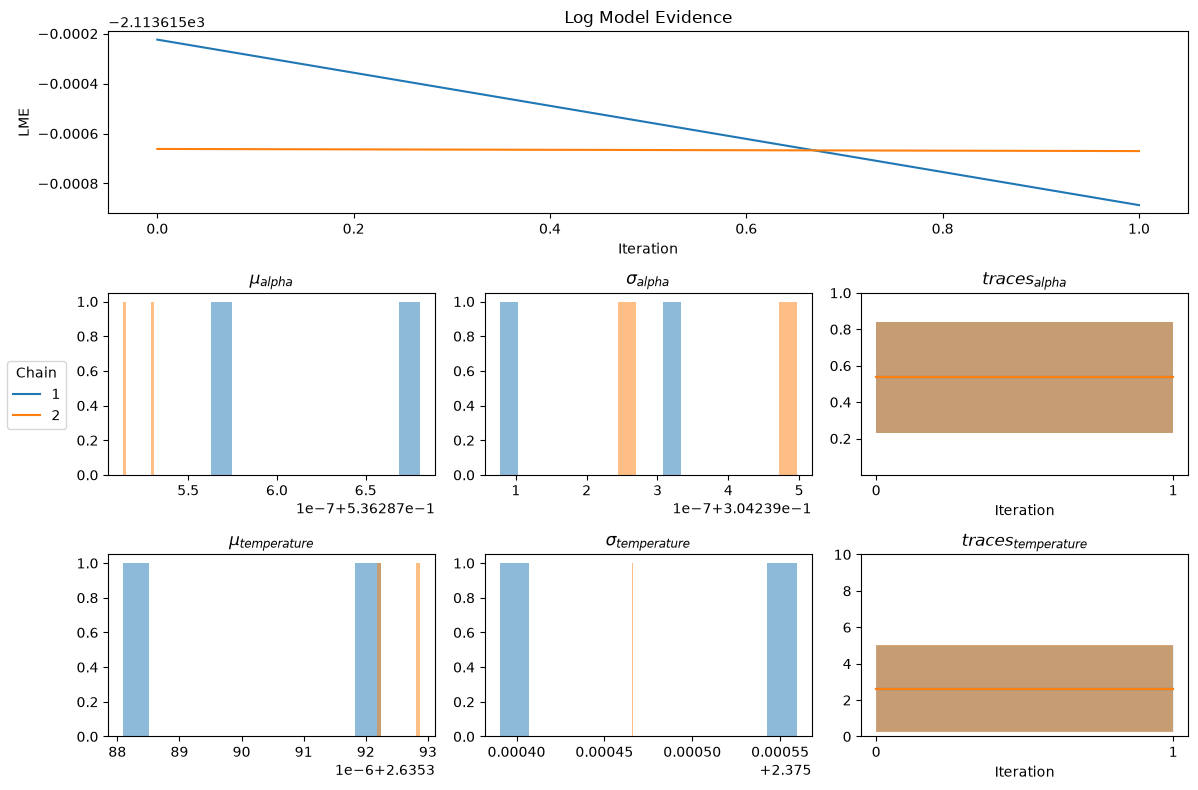

In [4]:
vb.diagnostics()

## The group-level estimates

`vb.hyperparameters` holds the estimated group mean (`mean`), its standard error (`mean_se`), and the group standard deviation (`sd`) of each parameter, for every iteration and chain.
We take the last iteration of the chain that reached the highest log model evidence.

In [5]:
hyperparameters = vb.hyperparameters
last = hyperparameters.groupby("chain").iteration.transform("max") == hyperparameters.iteration
final = hyperparameters[last]
best_chain = final.loc[final.lme.idxmax(), "chain"]
group = final[final.chain == best_chain].set_index("parameter")[["mean", "mean_se", "sd"]]
group["true mean"] = [0.6, 2]
group["true sd"] = [0.2, 1]
group.round(3)

,mean,mean_se,sd,true mean,true sd
parameter,,,,,
alpha,0.536,0.043,0.304,0.6,0.2
temperature,2.635,0.333,2.375,2.0,1.0


Because we know the uncertainty of the group means, we can test them.
[`ttest`](#cpm.hierarchical.VariationalBayes.ttest) runs a one-sample *t*-test of each group mean against a value of our choice; here, we test whether the group learning rate differs from 0.5, and the group inverse temperature from 5.

In [6]:
tests = vb.ttest(null={"alpha": 0.5, "temperature": 5})
last_iteration = final.loc[final.chain == best_chain, "iteration"].max()
tests = tests[(tests.chain == best_chain) & (tests.iteration == last_iteration)]
tests[["parameter", "mean", "mean_se", "null", "t_stat", "p_val"]].round(4)

,parameter,mean,mean_se,null,t_stat,p_val
6,alpha,0.5363,0.0426,0.5,0.8518,0.3983
7,temperature,2.6354,0.3326,5.0,-7.1088,0.0000


The group learning rate is not reliably different from 0.5, while the group inverse temperature is clearly lower than 5.
Note that the estimated group means are not exactly the true means of 0.6 and 2: with 50 participants and noisy choices, the group estimates are uncertain too, which is exactly what `mean_se` captures.

## The participant-level estimates

The estimates of every participant are stored in `vb.fit`.
We take the last estimates of the best chain, and compare them with the true parameters.

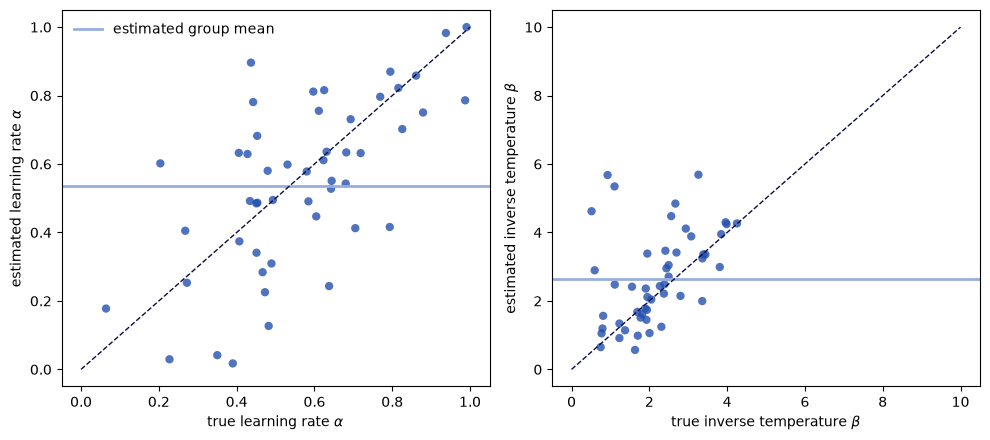

In [7]:
fits = vb.fit[vb.fit.chain == best_chain]
estimates = fits[fits.iteration == fits.iteration.max()].sort_values("ppt").reset_index(drop=True)

labels = {"alpha": r"learning rate $\alpha$", "temperature": r"inverse temperature $\beta$"}
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, name in zip(axes, labels):
    true = true_parameters[name]
    ax.scatter(true, estimates[name], alpha=0.8, color="#2350b0", edgecolor="none")
    ax.axhline(group.loc[name, "mean"], color="#98aedd", linewidth=2, label="estimated group mean")
    limits = [0, 1] if name == "alpha" else [0, 10]
    ax.plot(limits, limits, color="#0c0c45", linestyle="--", linewidth=1)
    ax.set_xlabel(f"true {labels[name]}")
    ax.set_ylabel(f"estimated {labels[name]}")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [8]:
errors = pd.Series(
    {name: np.mean(np.abs(estimates[name].to_numpy() - true_parameters[name].to_numpy())) for name in labels},
    name="mean absolute error",
)
errors.round(3)

alpha          0.149
temperature    0.854
Name: mean absolute error, dtype: float64

As with empirical Bayes, the estimates of participants with uninformative data are pulled towards the estimated group mean.
Compare the mean absolute errors with those of [Tutorial 4](hierarchical-empirical-bayes.ipynb), which used the same simulated participants.

## Summary and next steps

You estimated the group distribution of the parameters with variational Bayes, checked its convergence, and tested the group means against given values using their estimated uncertainty.

This completes the tutorials.
To see these methods applied to research questions, browse the [examples](../examples/index.md); to scale fits up to many participants, see the [how-to guides](../how-to/index.md).

## References

Piray, P., Dezfouli, A., Heskes, T., Frank, M. J., & Daw, N. D. (2019). Hierarchical Bayesian inference for concurrent model fitting and comparison for group studies. *PLoS Computational Biology*, 15(6), e1007043. https://doi.org/10.1371/journal.pcbi.1007043